# 2. From channel effects to a budget decision

This notebook converts the frozen posterior into incremental conversions, revenue, return on ad spend and marginal returns, then optimizes one shared allocation. Results are model-based estimates on simulated data, not realized business lift.

The historical reporting window is 2021-04-19 through 2023-07-17. For each channel, remove only its exposures within that window, retain earlier carryover and count outcomes inside the window. Outcomes after the window are excluded.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT=Path.cwd()
if not (ROOT/'reports').is_dir(): ROOT=ROOT.parent
assert (ROOT/'reports/data_audit.json').is_file(), 'Run from the repository root or notebooks directory.'
display(Markdown((ROOT/'reports/channel_results/table.md').read_text()))

| Channel | Spend (million CU) | Incremental conversions (million) | Incremental revenue (million CU) | Revenue share (%) | ROAS | Marginal ROAS |
|---|---:|---:|---:|---:|---:|---:|
| Channel0 | 29.74 | 3559.53 [1235.66, 6893.30] | 71.20 [24.72, 137.88] | 7.13 [2.47, 13.80] | 2.39 [0.83, 4.64] | 1.13 [0.47, 2.01] |
| Channel1 | 23.29 | 1664.95 [707.14, 3238.97] | 33.30 [14.14, 64.78] | 3.33 [1.42, 6.48] | 1.43 [0.61, 2.78] | 0.79 [0.39, 1.37] |
| Channel2 | 8.31 | 1305.53 [895.69, 1917.27] | 26.12 [17.92, 38.36] | 2.61 [1.79, 3.84] | 3.14 [2.16, 4.61] | 2.02 [1.32, 3.07] |
| Channel3 | 64.76 | 4922.44 [3773.57, 6146.39] | 98.45 [75.47, 122.94] | 9.85 [7.55, 12.30] | 1.52 [1.17, 1.90] | 1.06 [0.80, 1.32] |
| Channel4 | 34.77 | 2462.65 [1844.66, 3152.49] | 49.26 [36.90, 63.06] | 4.93 [3.69, 6.31] | 1.42 [1.06, 1.81] | 0.95 [0.69, 1.23] |


## Interpreting the table

ROAS divides incremental revenue by channel spend. Revenue is calculated region-week by region-week using its conversion value. Marginal ROAS is the local derivative when each channel's regional and weekly schedule scales proportionally at fixed impression prices. Neither quantity is profit ROI. Currency is unspecified in the source.

Intervals are 90% equal-tailed posterior credible intervals for expected effects. They exclude outcome noise and uncertainty about causal specification, future prices and conversion values. Positive effects are partly imposed by the coefficient parameterization; positive intervals are not independent causal evidence.

## Optimize a constrained allocation

Keep total historical spend fixed at 160.88 million currency units and bound each channel at 80%–120% of its original budget. Maximize posterior expected revenue using full nonlinear response curves. Choose **one allocation** and evaluate it under all 4,000 posterior draws; do not optimize each draw separately and average its solution.

The implementation checks exact gradients and optimality conditions for the concave objective. The ±20% bounds are planning assumptions, not identified safe intervention limits.

Expected gain: 2.64 million CU; 90% interval [-1.66, 6.84]
Conditional probability of improvement: 84.8%


| Channel | Original spend (million CU) | Optimized spend (million CU) | Change | Original mROAS | Optimized mROAS | Constraint |
|---|---:|---:|---:|---:|---:|---|
| Channel0 | 29.74 | 33.09 | +11.3% | 1.13 | 1.02 | interior |
| Channel1 | 23.29 | 18.63 | -20.0% | 0.79 | 0.93 | lower |
| Channel2 | 8.31 | 9.97 | +20.0% | 2.02 | 1.80 | upper |
| Channel3 | 64.76 | 68.53 | +5.8% | 1.06 | 1.02 | interior |
| Channel4 | 34.77 | 30.66 | -11.8% | 0.95 | 1.02 | interior |


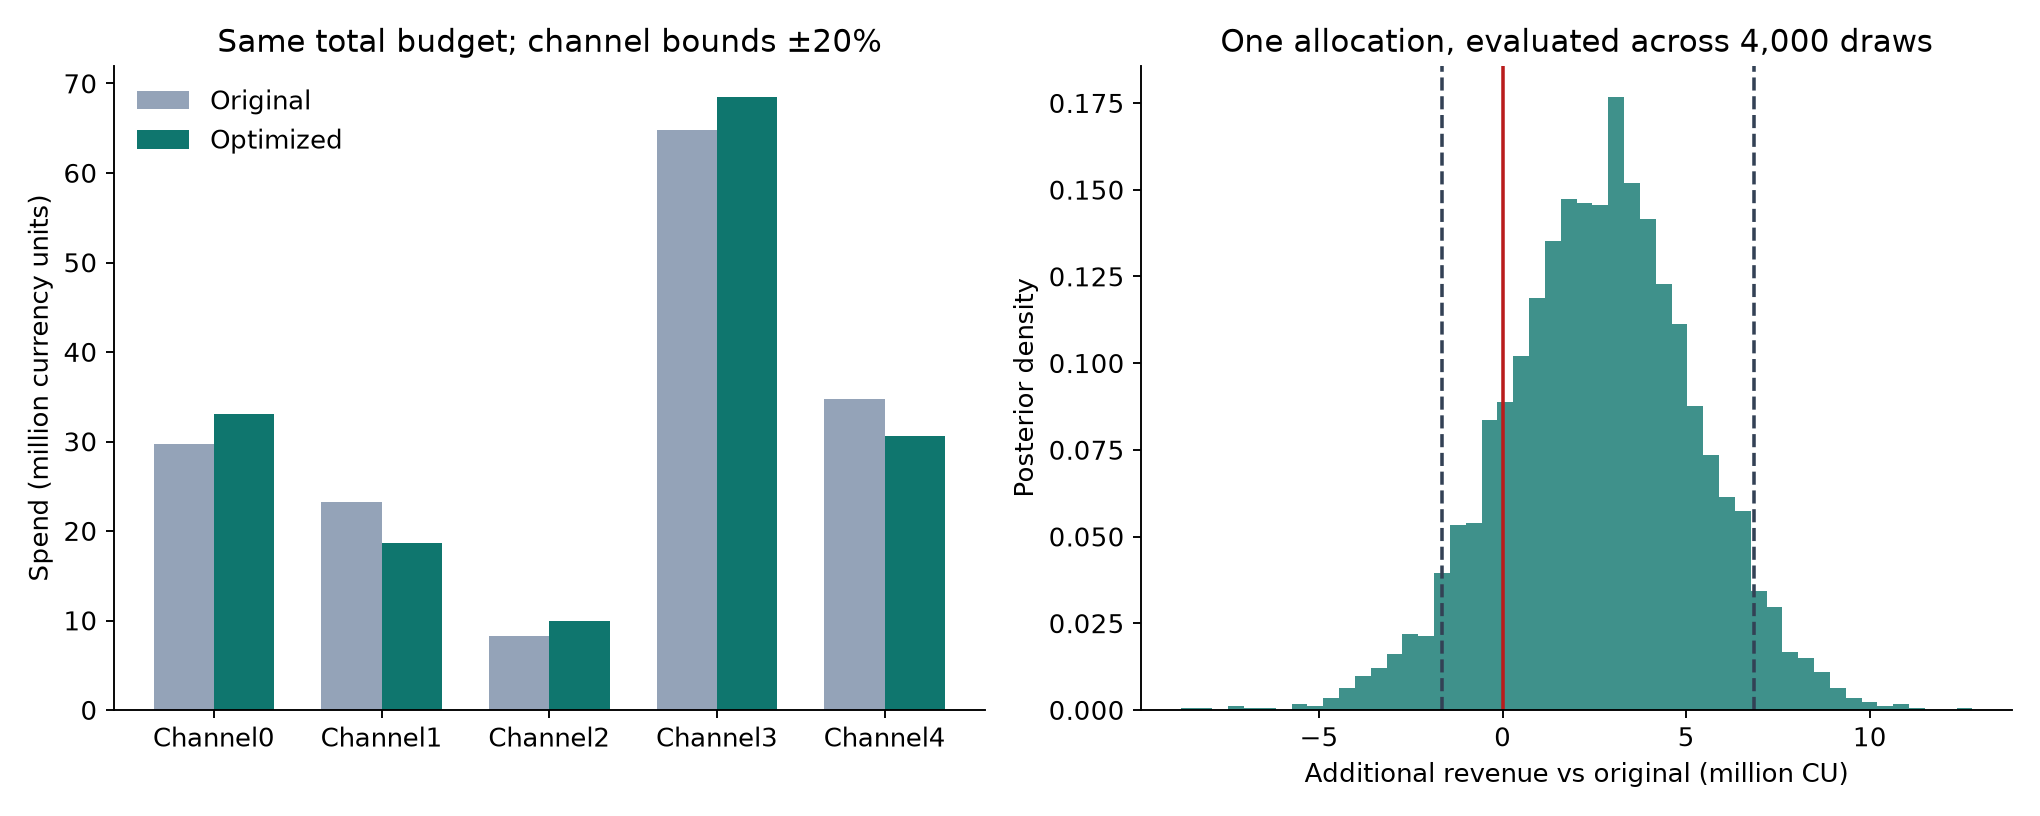

In [2]:
display(Markdown((ROOT/'reports/budget_optimization/allocation.md').read_text()))
s=json.loads((ROOT/'reports/budget_optimization/summary.json').read_text())
r=s['revenue_gain']
print(f"Expected gain: {r['mean']/1e6:.2f} million CU; 90% interval [{r['lo90']/1e6:.2f}, {r['hi90']/1e6:.2f}]")
print(f"Conditional probability of improvement: {s['probability_revenue_gain_positive']:.1%}")
display(Image(filename=str(ROOT/'reports/budget_optimization/budget_comparison.png')))

## Decision boundary

The original model estimates 2.64 million CU of additional revenue, with an interval spanning losses and gains. This is a historical reallocation candidate, not a deployment-ready future plan. It assumes stable response curves, prices, conversion values and control relationships. Inventory, margins and implementation costs are not modeled.

Next: `03_experimental_calibration.ipynb` shows how a new, explicitly hypothetical experimental summary changes beliefs and the decision.